### TASK 1

##### Line Plot(Sales Trend)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("car_prices.csv")
df.sample()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
232846,2004,Mazda,Mazda6,i,Sedan,automatic,1yvfp80c945n42859,va,19.0,128323.0,red,tan,chambersburg affordable auto sales llc,2675.0,2100.0,Wed Feb 11 2015 01:30:00 GMT-0800 (PST)


In [3]:
df['saledate'] = df['saledate'].fillna('')

In [4]:
df['saledate'] = df['saledate'].astype("str")

In [5]:
df['saledate'] = pd.to_datetime(df['saledate'],errors='coerce',utc = True)

C:\Users\swara\AppData\Local\Temp\ipykernel_16120\3433657043.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate'] = pd.to_datetime(df['saledate'],errors='coerce',utc = True)


In [6]:
df['month'] = df['saledate'].dt.month_name()

In [7]:
sell = df.groupby('month')['sellingprice'].sum()

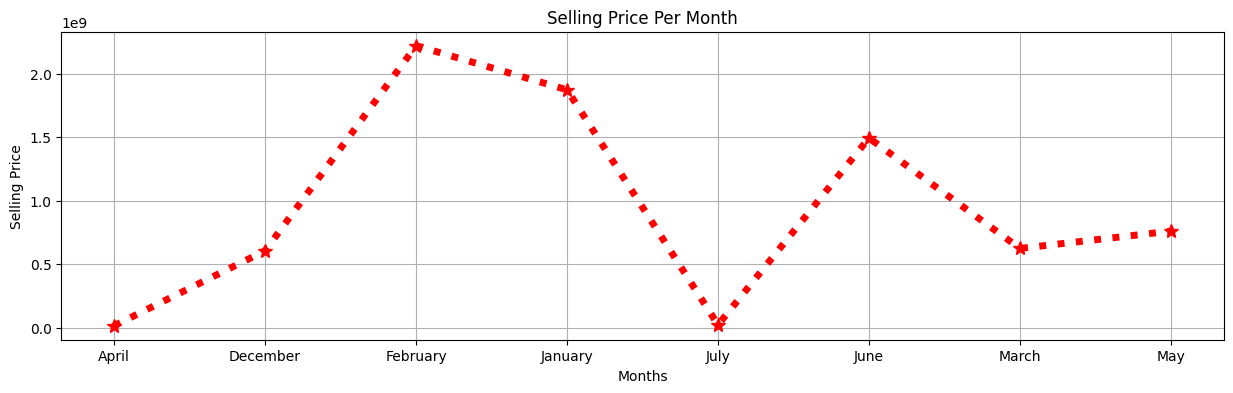

In [8]:
plt.figure(figsize=(15,4))
plt.title("Selling Price Per Month")
plt.xlabel("Months")
plt.ylabel("Selling Price")
plt.plot(sell.index,sell.values,color='red',marker='*',linestyle=':',linewidth=5,markersize=10)
plt.grid()
plt.show()

### TASK 2

##### Scatter Plot()

In [57]:
df.sample(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,month
22156,2005,Chevrolet,Malibu Maxx,LT,Hatchback,automatic,1g1zu64875f143782,mi,28.0,134927.0,red,beige,modern financial services,2425.0,1900.0,2014-12-18 01:30:00+00:00,December
36235,2012,Ford,Focus,SE,Sedan,automatic,1fahp3f29cl175736,il,2.0,66512.0,white,black,ally,8075.0,6500.0,2014-12-18 02:00:00+00:00,December
222561,2012,Kia,Sportage,Base,SUV,automatic,kndpb3a29c7348451,fl,4.0,19945.0,red,black,suntrust bank,14300.0,14600.0,2015-02-03 17:10:00+00:00,February
297748,2005,Dodge,Magnum,RT,Wagon,automatic,2d8gv58225h596073,ca,24.0,132077.0,silver,gray,logistics leasing,5100.0,6500.0,2015-02-10 20:30:00+00:00,February
254978,2015,Kia,Optima,LX,Sedan,automatic,knagm4a76f5551970,ca,5.0,2266.0,gray,beige,kia motors finance,16000.0,18200.0,2015-02-09 20:30:00+00:00,February


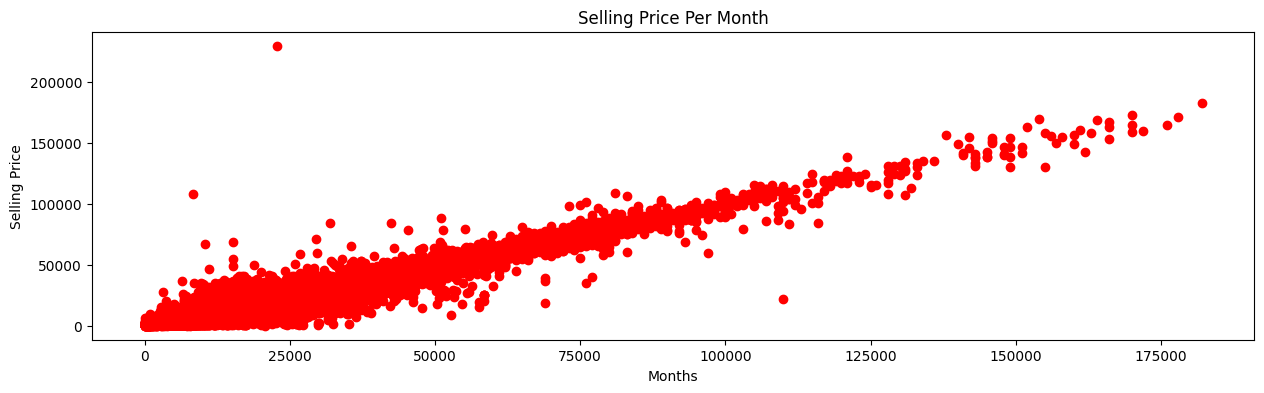

In [62]:
plt.figure(figsize=(15,4))
plt.title("Selling Price Per Month")
plt.xlabel("Months")
plt.ylabel("Selling Price")
plt.scatter(df['mmr'],df['sellingprice'],color='red')
plt.show()

### TASK 3

##### Bar Plot ()

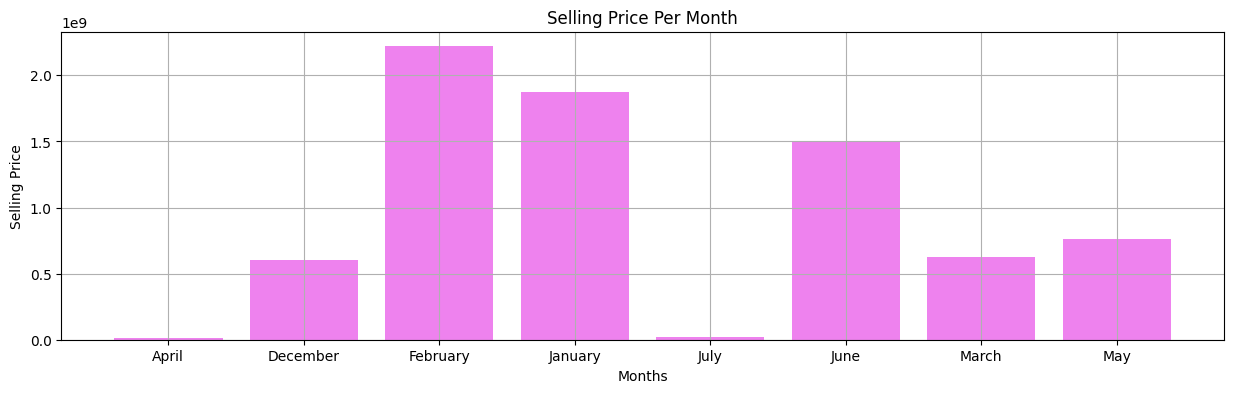

In [12]:
##Vertical Bar Plot
plt.figure(figsize=(15,4))
plt.title("Selling Price Per Month")
plt.xlabel("Months")
plt.ylabel("Selling Price")
plt.bar(sell.index,sell.values,color='violet')
plt.grid()
plt.show()

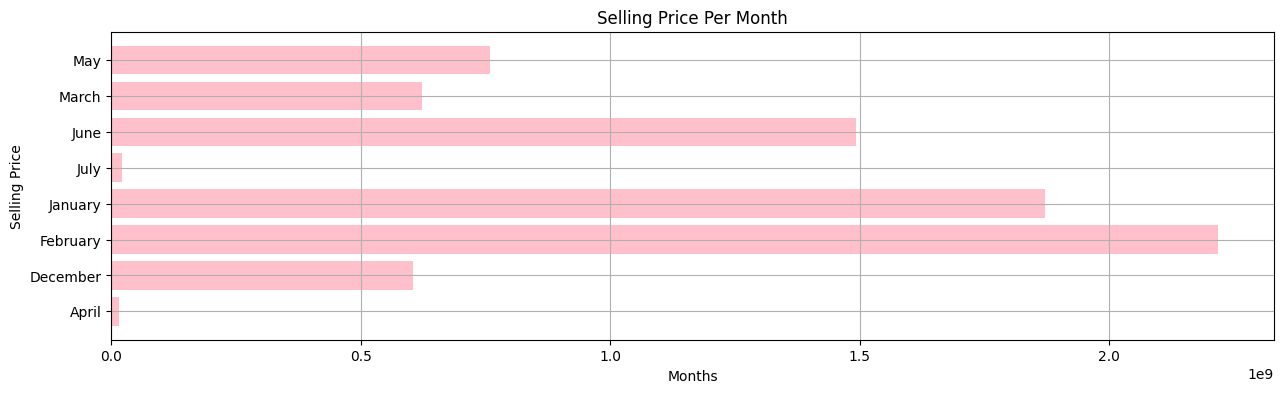

In [13]:
#Vertical Bar Plot
plt.figure(figsize=(15,4))
plt.title("Selling Price Per Month")
plt.xlabel("Months")
plt.ylabel("Selling Price")
plt.barh(sell.index,sell.values,color='pink')
plt.grid()
plt.show()

### TASK 4

##### Multiple Bar Plot()

In [14]:
m = df[(df['make']=='Toyota')&(df['year']>=2008)&(df['year']<=2015)]
n = df[(df['make']=='Hyundai')&(df['year']>=2008)&(df['year']<=2015)]
o = df[(df['make']=='Ford')&(df['year']>=2008)&(df['year']<=2015)]

In [15]:
p = m.groupby("year")['sellingprice'].sum()
q = n.groupby("year")['sellingprice'].sum()
r = o.groupby("year")['sellingprice'].sum()

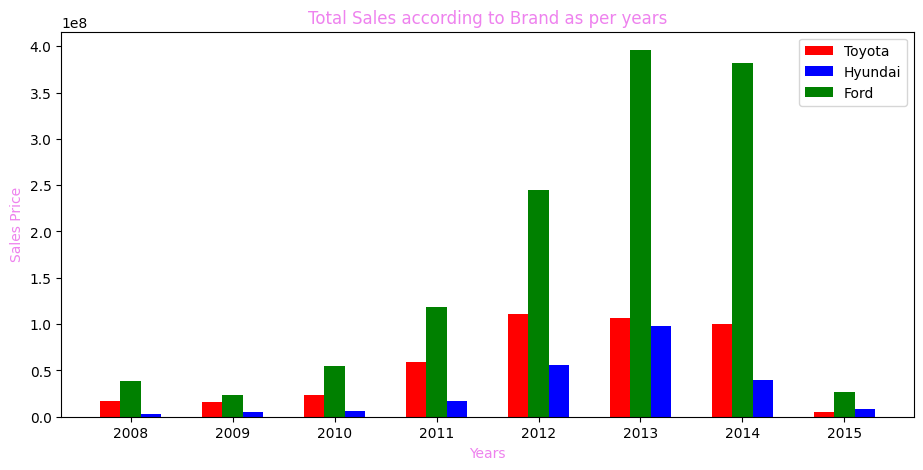

In [16]:
plt.figure(figsize=(11,5))
plt.title("Total Sales according to Brand as per years",color='violet')
plt.xlabel("Years",color='violet')
plt.ylabel("Sales Price",color='violet')
plt.bar(np.arange(p.shape[0])-0.2,p.values,color='red',width=0.2,label='Toyota')
plt.bar(np.arange(q.shape[0])+0.2,q.values,color='blue',width=0.2,label='Hyundai')
plt.bar(np.arange(p.shape[0]),r.values,color='green',width=0.2,label='Ford')
plt.xticks(np.arange(p.shape[0]),p.index)
plt.legend()
plt.show()

### TASK 5

##### Stacked Bar Chart()

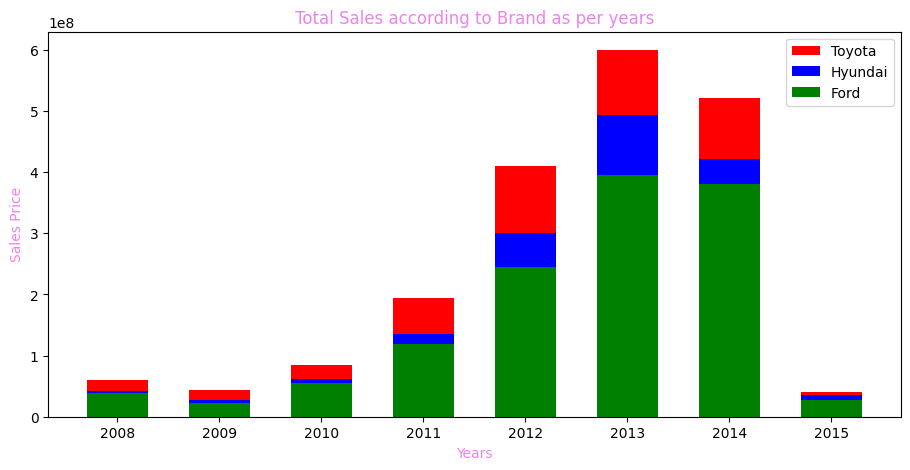

In [17]:
plt.figure(figsize=(11,5))
plt.title("Total Sales according to Brand as per years",color='violet')
plt.xlabel("Years",color='violet')
plt.ylabel("Sales Price",color='violet')
plt.bar(p.index,p.values,color='red',width=0.6,label='Toyota',bottom=q.values+r.values)
plt.bar(q.index,q.values,color='blue',width=0.6,label='Hyundai',bottom=r.values)
plt.bar(r.index,r.values,color='green',width=0.6,label='Ford')
plt.legend()
plt.show()

### TASK 6

##### Histogram(Marks Distribution)

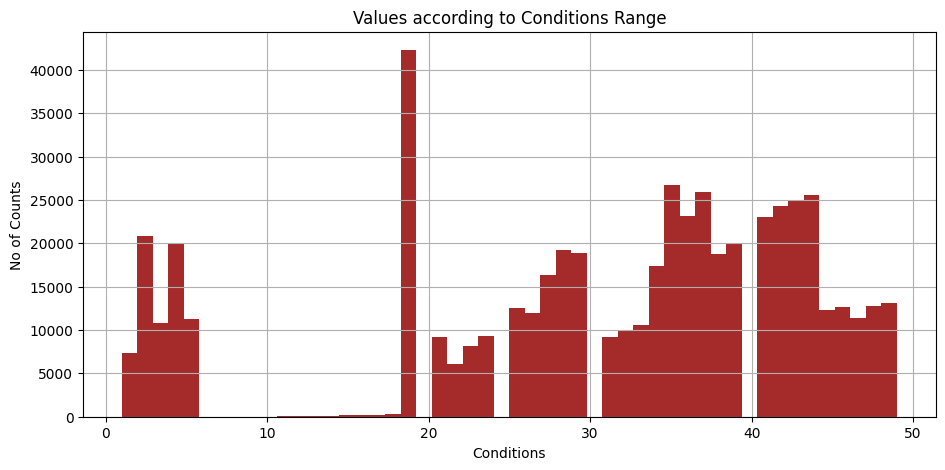

In [53]:
plt.figure(figsize=(11,5))
plt.title("Values according to Conditions Range")
plt.xlabel("Conditions")
plt.ylabel("No of Counts")
plt.hist(df['condition'],bins=50,color='brown')
plt.grid()
plt.show()

In [56]:
'As we can see from this histogram there are negligible no of counts between 7 and 20 except there is a highest jump of values on 19.0 condition and the rest 20 to 50 have evenly distributed no of counts'

'As we can see from this histogram there are negligible no of counts between 7 and 20 except there is a highest jump of values on 19.0 condition and the rest 20 to 50 have evenly distributed no of counts'

### TASK 7

##### Pie Chart(Market Share)

In [28]:
bt = df['body'].value_counts().head(10)

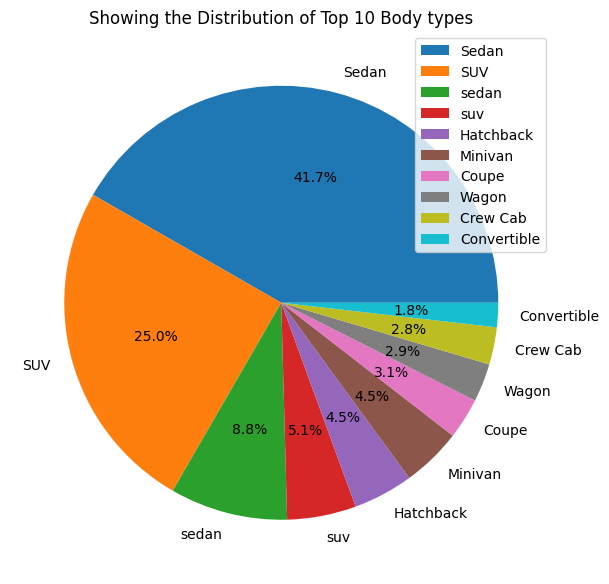

In [30]:
plt.figure(figsize=(7,14))
plt.title("Showing the Distribution of Top 10 Body types")
plt.pie(bt,labels = bt.index,autopct='%0.1f%%')
plt.legend()
plt.show()

In [38]:
'''This Pie Chart demonstrates the distribution of only 10 body types out of 87 as we can show from this graph that the last index which is convertible is only about 1.8%
so if i would include also the other values that would come out to be less than 1% that doesn't make any sense and also that would make this more complex and unreable for us
as also we can see the Sedan is leading the sell with nearly 42% and after that in 2nd position it is SUV with 25% sells these two combinly cover 67% sells and the other body types are less than 10%'''

"This Pie Chart demonstrates the distribution of only 10 body types out of 87 as we can show from this graph that the last index which is convertible is only about 1.8%\nso if i would include also the other values that would come out to be less than 1% that doesn't make any sense and also that would make this more complex and unreable for us\nas also we can see the Sedan is leading the sell with nearly 42% and after that in 2nd position it is SUV with 25% sells these two combinly cover 67% sells and the other body types are less than 10%"